In [ ]:
import torch
from torch import nn
from torch import Tensor
from torch import optim
import torch.nn.functional as F


In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/usr/ebuild/installs/software/Anaconda3/2024.02-1/lib/python3.11/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['plt']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# Device and seed setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

# === Load dataset ===
data = pd.read_csv("spatial_avg_data-ERAsinglelevel_2020-24_daily.csv")

# === Extract relevant features ===
s_data = data[["asn", "rsn", "siconc"]].values

# === Train-test split ===
train_data = s_data[:5461]
test_data = s_data[5461:6050]

# === Scale features using only training stats ===
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# === Define constants for computing snow depth proxy ===
A, B = 600, 300

def compute_snow_depth_proxy(data):
    siconc_term = (data[:, 2] * A) / (A - B)
    albedo_density_term = (data[:, 0] * data[:, 1]) / (A - B)
    return (siconc_term + albedo_density_term).reshape(-1, 1)

# === Compute and normalize snow depth proxy ===
train_depth = compute_snow_depth_proxy(train_scaled)
test_depth = compute_snow_depth_proxy(test_scaled)

mean_depth, std_depth = train_depth.mean(), train_depth.std()
train_depth_norm = (train_depth - mean_depth) / std_depth
test_depth_norm = (test_depth - mean_depth) / std_depth

# === Convert to sequences ===
def create_sequences(inputs, targets, seq_len):
    X, Y = [], []
    for i in range(len(inputs) - seq_len + 1):
        X.append(inputs[i:i+seq_len])
        Y.append(targets[i:i+seq_len])  # supervision at end of sequence
    return np.array(X), np.array(Y)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(train_scaled[:, 1:2], train_depth_norm, seq_length)  # only snow density as input
X_test_seq, y_test_seq = create_sequences(test_scaled[:, 1:2], test_depth_norm, seq_length)

# === Convert to PyTorch tensors ===
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

# === Confirm shapes ===
print(f"Train X shape: {X_train_tensor.shape}, y shape: {y_train_tensor.shape}")
print(f"Test X shape: {X_test_tensor.shape}, y shape: {y_test_tensor.shape}")


Train X shape: torch.Size([5452, 10, 1]), y shape: torch.Size([5452, 10, 1])
Test X shape: torch.Size([580, 10, 1]), y shape: torch.Size([580, 10, 1])


In [ ]:
!pip install torchdiffeq

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchdiffeq import odeint

# Data Augmentation Function for Contrastive Learning
def augment_data(x, noise_std=0.01):
    noise = torch.randn_like(x) * noise_std  # Add Gaussian noise
    x_aug = x + noise
    return x_aug

# === ODE Function ===
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, t, h):
        return self.net(h)

# === Attention Block ===
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionBlock, self).__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attention_weights = self.softmax(torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(Q.shape[-1]))
        return torch.matmul(attention_weights, V)

# === Contrastive Loss ===
def contrastive_loss(z_i, z_j, scale=0.05):
    batch_size = z_i.size(0)

    z_i = F.normalize(z_i, dim=1)
    z_j = F.normalize(z_j, dim=1)

    combined_z = torch.cat([z_i, z_j], dim=0)
    combined_similarity = torch.matmul(combined_z, combined_z.T) / scale

    labels = torch.arange(batch_size, device=z_i.device)
    combined_labels = torch.cat([labels, labels], dim=0)

    mask = ~torch.eye(combined_labels.shape[0], device=combined_labels.device).bool()
    combined_similarity = combined_similarity.masked_select(mask).view(combined_labels.shape[0], -1)

    loss = F.cross_entropy(combined_similarity, combined_labels)
    return loss

# === Final Model: ODE Contrastive Model with Attention ===
class ODEContrastiveWithAttention(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1):
        super(ODEContrastiveWithAttention, self).__init__()
        self.hidden_dim = hidden_dim

        # Map input to hidden state
        self.initial_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # ODE dynamics
        self.odefunc = ODEFunc(hidden_dim)

        # Attention
        self.attention = AttentionBlock(hidden_dim)

        # Output branches
        self.fc_depth = nn.Linear(hidden_dim, output_dim)
        self.fc_params = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x, x_aug):
        batch_size, seq_len, _ = x.size()

        # === Encode x ===
        h0 = self.initial_mlp(x[:, 0, :])  # initial hidden from first time step
        t = torch.linspace(0, 1, steps=seq_len).to(x.device)
        h_ode = odeint(self.odefunc, h0, t)  # (seq_len, batch, hidden_dim)
        enc_x = h_ode.permute(1, 0, 2)       # (batch, seq_len, hidden_dim)
        attn_x = self.attention(enc_x)

        # === Encode x_aug ===
        h0_aug = self.initial_mlp(x_aug[:, 0, :])
        h_ode_aug = odeint(self.odefunc, h0_aug, t)
        enc_aug = h_ode_aug.permute(1, 0, 2)
        attn_aug = self.attention(enc_aug)

        # === Depth prediction ===
        depth_pred = self.fc_depth(attn_x).squeeze(-1)

        # === Parameter estimation from last hidden state ===
        last_out = attn_x[:, -1, :]  # (batch, hidden_dim)
        params_pred = self.fc_params(last_out)
        w_raw, b_raw, c_raw = params_pred[:, 0:1], params_pred[:, 1:2], params_pred[:, 2:3]

        # Apply correct activations/scalings
        w = torch.sigmoid(w_raw) * 2.0 - 1.0
        b = torch.exp(b_raw)
        c = torch.tanh(c_raw) * 10.0

        mean_density = x[:, :, 0].mean(dim=1, keepdim=True)
        w_exp = w.expand_as(depth_pred)
        b_exp = b.expand_as(depth_pred)
        c_exp = c.expand_as(depth_pred)
        mean_density_exp = mean_density.expand_as(depth_pred)

        estimated_snow_depth = w_exp * mean_density_exp + b_exp * depth_pred + c_exp

        # === Contrastive Loss ===
        contrastive_loss_val = contrastive_loss(attn_x[:, -1, :], attn_aug[:, -1, :]).mean()

        return depth_pred, params_pred, estimated_snow_depth, contrastive_loss_val


Let's use 2 GPUs!


/home/asampath/.local/lib/python3.11/site-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/home/asampath/.local/lib/python3.11/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/tmp/ipykernel_3406161/321110783.py:55: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  l1_norm = sum(p.abs().sum() for p in model.parameters())
/tmp/ipykernel_3406161/321110783.py:60: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will gi

Epoch 0/500, Loss: 5.1103
Epoch 50/500, Loss: 3.4637
Epoch 100/500, Loss: 3.4170
Epoch 150/500, Loss: 3.4136
Epoch 200/500, Loss: 3.3824
Epoch 250/500, Loss: 3.3739
Epoch 300/500, Loss: 3.3521
Epoch 350/500, Loss: 3.3647
Epoch 400/500, Loss: 3.3583
Epoch 450/500, Loss: 3.3478
(580, 10)
(580, 10)
Training results saved to training_results.pth
Data successfully written to average_depths.csv


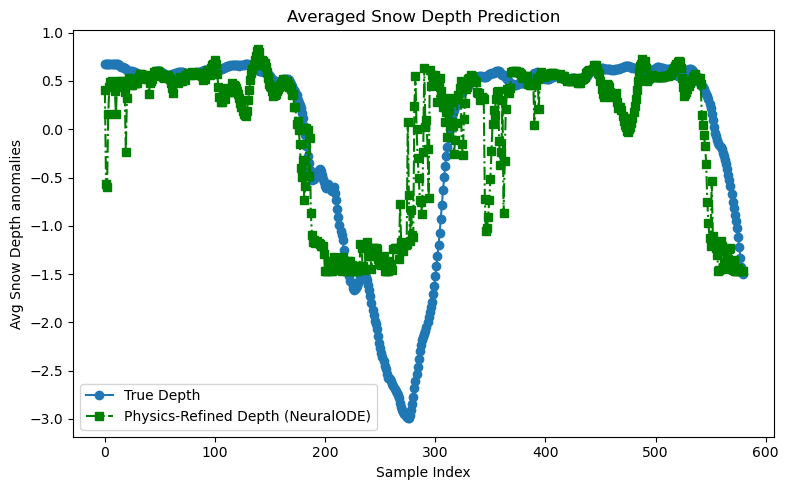

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Initialize Model & Optimizer ===
model = ODEContrastiveWithAttention()  # Move model to device
criterion_depth = nn.MSELoss()  # Loss for depth prediction
criterion_estimated_snow_depth = nn.MSELoss()  # Loss for predicted
optimizer = optim.Adam(model.parameters(), lr=0.0005) # removed weight_decay from here.

# Check for multiple GPUs and wrap with DataParallel if available
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# Move model to device
model = model.to(device)

# === Training Setup ===
epochs = 500
batch_size = 16

# Convert data to PyTorch datasets
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# === Store losses & predictions ===
train_losses = []

# === Training Loop ===
for epoch in range(epochs):
    total_loss = 0
    model.train()  # Set to training mode

    for batch_x, batch_y in train_dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)  # move batch to device.
        optimizer.zero_grad()
        batch_x_aug = augment_data(batch_x)
        # Correct Forward Pass
        depth_pred, params_pred, estimated_snow_depth_pred, contrastive_loss_value = model(batch_x, batch_x_aug)
        loss_depth = criterion_depth(depth_pred, batch_y[:, -1, :])
        loss_estimated_snow_depth = criterion_depth(estimated_snow_depth_pred, batch_y[:, -1, :])
        contrastive_loss_value = torch.mean(contrastive_loss_value)  # Ensure scalar
        loss = loss_depth + loss_estimated_snow_depth + contrastive_loss_value

        # L1 Regularization
        l1_lambda = 0.001  # Adjust lambda as needed
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss += l1_lambda * l1_norm

        #L2 Regularization
        l2_lambda = 1e-5 #adjust lambda as needed.
        l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
        loss+= l2_lambda * l2_norm

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Store loss for visualization
    train_losses.append(total_loss / len(train_dataloader))

    # Print Progress Every 50 Epochs
    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {train_losses[-1]:.4f}")

# === After Training: Evaluate on Test Set ===
model.eval()
depth_predictions = []
estimated_depth_predictions = []
with torch.no_grad():
    for batch_x, _ in test_dataloader:
        batch_x = batch_x.to(device)
        batch_x_aug = augment_data(batch_x)  # create augmented data.
        depth_pred, params_pred, estimated_snow_depth, contrastive_loss_value = model(batch_x, batch_x_aug)  # unpack 4 values.
        depth_predictions.append(depth_pred.cpu())
        estimated_depth_predictions.append(estimated_snow_depth.cpu())

# Convert Predictions to NumPy
estimated_depth_predictions_np = torch.cat(estimated_depth_predictions).squeeze().numpy()
depth_predictions_np = torch.cat(depth_predictions).squeeze().numpy()
true_depths_np = y_test_tensor.cpu().squeeze().numpy()
print(depth_predictions_np.shape)
print(true_depths_np.shape)
avg_pred = depth_predictions_np.mean(axis=1)
avg_est = estimated_depth_predictions_np.mean(axis=1)
avg_true = true_depths_np.mean(axis=1)
# === Save Training Results ===
torch.save(
    {
        "epoch": epochs,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "depth_predictions_np": depth_predictions_np,
        "estimated_depth_predictions_np": estimated_depth_predictions_np,
        "true_depths_np": true_depths_np,
    },
    "NeuralODE-training_results.pth",
)
print("Training results saved to training_results.pth")

# === Write to CSV file ===
df = pd.DataFrame({
    'avg_pred': avg_pred,
    'avg_est': avg_est,
    'avg_true': avg_true
})

# Write to a CSV file
df.to_csv('NeuralODE-average_depths.csv', index=False)  # index=False prevents writing the row numbers to the CSV
print("Data successfully written to average_depths.csv")

is limits between 0 and 1
plt.show()

In [ ]:
# Arrays: shape (samples, timesteps)
# depth_predictions_np         → LSTM prediction
# estimated_depth_predictions_np → Physics-refined prediction
# true_depths_np               → Ground truth

from sklearn.metrics import mean_squared_error

# === Overall metrics (flattened)
mse_lstm = mean_squared_error(true_depths_np.flatten(), depth_predictions_np.flatten())
rmse_lstm = np.sqrt(mse_lstm)
mean_lstm = depth_predictions_np.mean()

mse_phys = mean_squared_error(true_depths_np.flatten(), estimated_depth_predictions_np.flatten())
rmse_phys = np.sqrt(mse_phys)
mean_phys = estimated_depth_predictions_np.mean()

mean_true = true_depths_np.mean()

print("Prediction:")
print(f"  MSE  = {mse_lstm:.4f}")
print(f"  RMSE = {rmse_lstm:.4f}")
print(f"  Mean = {mean_lstm:.4f}\n")

print("Physics-Refined Prediction:")
print(f"  MSE  = {mse_phys:.4f}")
print(f"  RMSE = {rmse_phys:.4f}")
print(f"  Mean = {mean_phys:.4f}\n")

print("Ground Truth Mean:")
print(f"  Mean = {mean_true:.4f}")


Prediction:
  MSE  = 0.5066
  RMSE = 0.7117
  Mean = -0.0136

Physics-Refined Prediction:
  MSE  = 0.4926
  RMSE = 0.7018
  Mean = 0.0167

Ground Truth Mean:
  Mean = 0.0152
